# 02 — Evaluare Clasificator (Stage 2)

Evaluează un **clasificator YOLOv8** pe split-ul `val` sau `test` și generează:
- Accuracy, Macro-Precision, Macro-Recall, Macro-F1
- Metrici per clasă
- **Confusion matrix** vizualizată
- CSV cu predicțiile individuale
- Comparare experimente B1 / B2 / B3

**Pre-condiție**: Ai rulat `notebooks/training/02_train_classifier.ipynb`.

In [3]:
import csv
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_recall_fscore_support
)

REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ultralytics import YOLO

print(f"Rădăcina proiectului: {REPO_ROOT}")

Rădăcina proiectului: D:\TrashDetectionSystem


In [4]:
# ── CONFIG ────────────────────────────────────────────────────────────────────

MODEL_PATH   = REPO_ROOT / "runs" / "classify" / "parks-cls-B2" / "weights" / "best.pt"
DATA_ROOT    = REPO_ROOT / "datasets" / "trashnet_cls"  # B2 — TrashNet
EVAL_SPLIT   = "test"       # "val" sau "test"
IMGSZ        = 224
DEVICE       = "0"          # "0" = GPU RTX 3050 | "cpu"
CLASSES      = ["glass", "metal", "other", "paper", "plastic"]
IMAGE_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

OUTPUT_DIR   = REPO_ROOT / "runs" / "classify_eval" / MODEL_PATH.parent.parent.name
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model    : {MODEL_PATH}")
print(f"Dataset  : {DATA_ROOT.name}  split={EVAL_SPLIT}")
print(f"Output   : {OUTPUT_DIR}")


Model    : D:\TrashDetectionSystem\runs\classify\parks-cls-B2\weights\best.pt
Dataset  : trashnet_cls  split=test
Output   : D:\TrashDetectionSystem\runs\classify_eval\parks-cls-B2


---
## Evaluare
Rulează inferența pe toate imaginile din split-ul ales și calculează metricile.

In [5]:
assert MODEL_PATH.exists(), f"Modelul nu există: {MODEL_PATH}"
split_dir = DATA_ROOT / EVAL_SPLIT
assert split_dir.exists(), f"Split-ul nu există: {split_dir}"

model = YOLO(str(MODEL_PATH))

# Index <int_id> → class_name conform modelului
raw_names = getattr(model, "names", {})
model_names = ({int(k): str(v) for k, v in raw_names.items()} if isinstance(raw_names, dict)
               else {i: str(n) for i, n in enumerate(raw_names)})

# Colectare date de evaluare
y_true, y_pred, rows = [], [], []

predict_kwargs = {"imgsz": IMGSZ, "verbose": False}
if DEVICE: predict_kwargs["device"] = DEVICE

for cls in CLASSES:
    cls_dir = split_dir / cls
    if not cls_dir.exists(): continue
    imgs = sorted(p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS)
    for img in imgs:
        res   = model.predict(str(img), **predict_kwargs)[0]
        probs = getattr(res, "probs", None)
        if probs is None: continue
        top_idx  = int(probs.top1)
        top_conf = float(probs.top1conf.item() if hasattr(probs.top1conf, "item") else probs.top1conf)
        pred_cls = model_names.get(top_idx, str(top_idx))
        y_true.append(cls); y_pred.append(pred_cls)
        rows.append({"image_path": img.as_posix(), "true_label": cls, "pred_label": pred_cls,
                     "pred_conf": top_conf, "correct": pred_cls == cls})

print(f"Imagini evaluate: {len(y_true)}")

Imagini evaluate: 257


In [6]:
# Calcul metrici
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=CLASSES, average=None, zero_division=0)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=CLASSES, average="macro", zero_division=0)
matrix = confusion_matrix(y_true, y_pred, labels=CLASSES)

# Afișare
print(f"\n{'='*55}")
print(f"  Accuracy         : {accuracy:.4f}")
print(f"  Macro Precision  : {macro_p:.4f}")
print(f"  Macro Recall     : {macro_r:.4f}")
print(f"  Macro F1         : {macro_f1:.4f}")
print(f"{'='*55}")
print(f"\n{'Clasa':<12} {'P':>8} {'R':>8} {'F1':>8} {'Support':>9}")
print("-" * 50)
for cls, p, r, f, s in zip(CLASSES, precision, recall, f1, support):
    print(f"{cls:<12} {p:>8.4f} {r:>8.4f} {f:>8.4f} {int(s):>9}")

# Salvare CSV predicții
pred_csv = OUTPUT_DIR / f"predictions_{EVAL_SPLIT}.csv"
with pred_csv.open("w", encoding="utf-8", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=["image_path","true_label","pred_label","pred_conf","correct"])
    w.writeheader(); w.writerows(rows)

# Salvare summary JSON
summary = {
    "model": str(MODEL_PATH), "dataset": str(DATA_ROOT), "split": EVAL_SPLIT,
    "num_images": len(y_true), "accuracy": accuracy,
    "macro_precision": macro_p, "macro_recall": macro_r, "macro_f1": macro_f1,
    "per_class": {cls: {"precision": float(p), "recall": float(r), "f1": float(f), "support": int(s)}
                  for cls, p, r, f, s in zip(CLASSES, precision, recall, f1, support)},
}
summary_json = OUTPUT_DIR / f"summary_{EVAL_SPLIT}.json"
summary_json.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(f"\nPredictions CSV : {pred_csv}")
print(f"Summary JSON    : {summary_json}")


  Accuracy         : 0.9222
  Macro Precision  : 0.8920
  Macro Recall     : 0.8958
  Macro F1         : 0.8938

Clasa               P        R       F1   Support
--------------------------------------------------
glass          0.8846   0.9020   0.8932        51
metal          0.8372   0.8780   0.8571        41
other          0.8000   0.8000   0.8000        15
paper          0.9798   0.9604   0.9700       101
plastic        0.9583   0.9388   0.9485        49

Predictions CSV : D:\TrashDetectionSystem\runs\classify_eval\parks-cls-B2\predictions_test.csv
Summary JSON    : D:\TrashDetectionSystem\runs\classify_eval\parks-cls-B2\summary_test.json


---
## Confusion Matrix

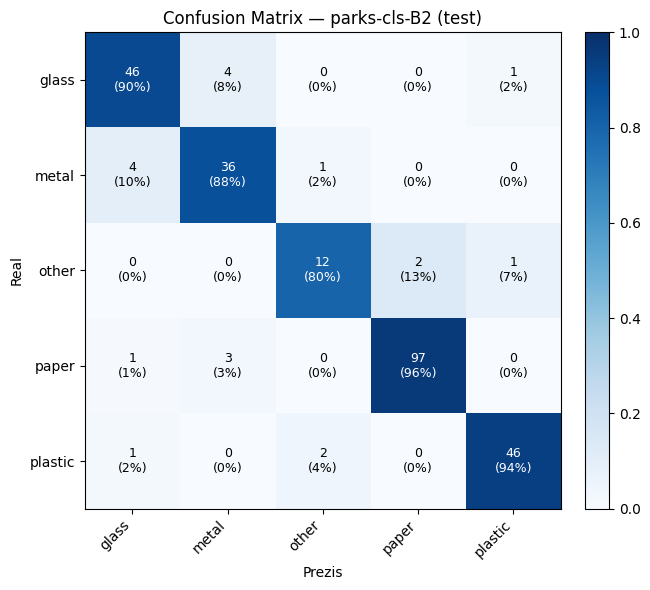

Confusion matrix salvată: D:\TrashDetectionSystem\runs\classify_eval\parks-cls-B2\confusion_matrix_test.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

# Normalizare pe rânduri (recall per clasă)
matrix_norm = matrix.astype(float) / (matrix.sum(axis=1, keepdims=True) + 1e-9)

im = ax.imshow(matrix_norm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)

ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Prezis"); ax.set_ylabel("Real")
ax.set_title(f"Confusion Matrix — {MODEL_PATH.parent.parent.name} ({EVAL_SPLIT})")

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        count = matrix[i, j]
        pct   = matrix_norm[i, j]
        color = "white" if pct > 0.6 else "black"
        ax.text(j, i, f"{count}\n({pct:.0%})", ha="center", va="center", fontsize=9, color=color)

plt.tight_layout()

cm_path = OUTPUT_DIR / f"confusion_matrix_{EVAL_SPLIT}.png"
plt.savefig(str(cm_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Confusion matrix salvată: {cm_path}")

---
## Vizualizare predicții corecte și greșite

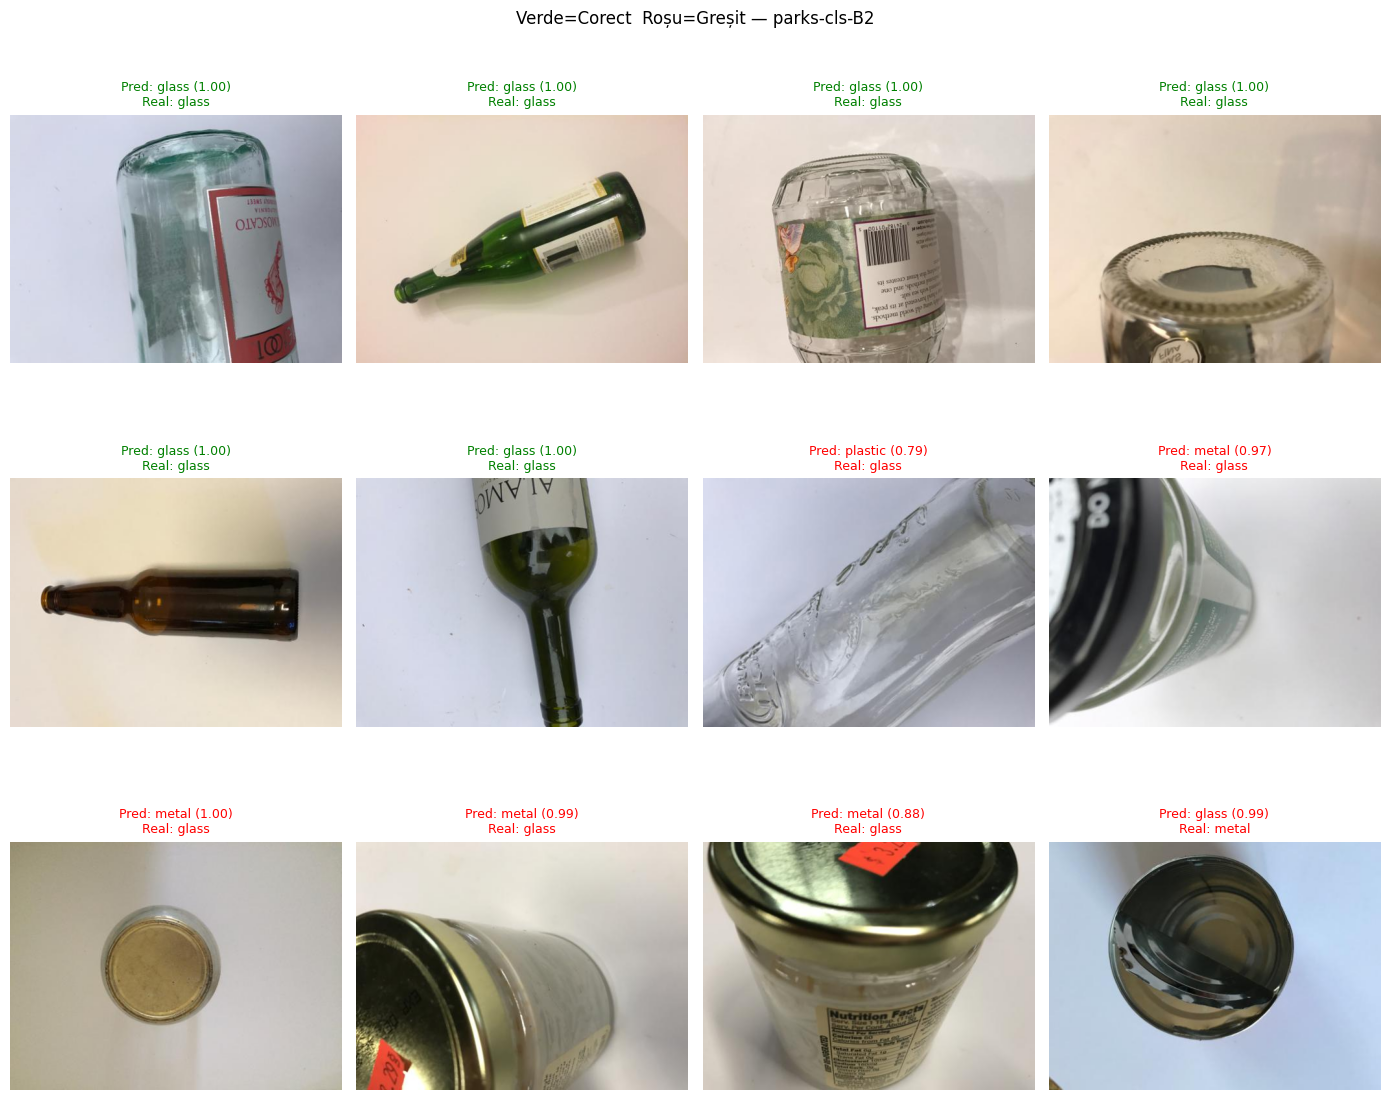

In [8]:
import cv2

N_SHOW = 12

correct_rows   = [r for r in rows if r["correct"]][:N_SHOW//2]
incorrect_rows = [r for r in rows if not r["correct"]][:N_SHOW//2]
selected       = correct_rows + incorrect_rows

if not selected:
    print("Nicio predicție disponibilă pentru vizualizare.")
else:
    cols = 4
    rows_count = (len(selected) + cols - 1) // cols
    fig, axes = plt.subplots(rows_count, cols, figsize=(14, 4*rows_count))
    axes = np.array(axes).flatten()

    for ax, row in zip(axes, selected):
        img = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        color = "green" if row["correct"] else "red"
        label = f"Pred: {row['pred_label']} ({row['pred_conf']:.2f})\nReal: {row['true_label']}"
        ax.set_title(label, color=color, fontsize=9)
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

    for ax in axes[len(selected):]:
        ax.axis("off")

    plt.suptitle(f"Verde=Corect  Roșu=Greșit — {MODEL_PATH.parent.parent.name}", fontsize=12)
    plt.tight_layout()
    plt.show()

---
## Comparare Experimente B1 / B2 / B3

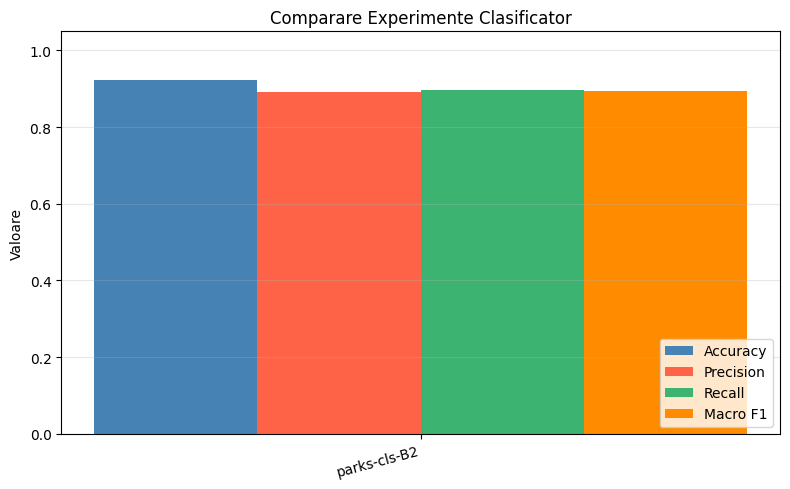


Run                            Acc        P        R       F1
--------------------------------------------------------------
parks-cls-B2                0.9222   0.8920   0.8958   0.8938


In [ ]:
summaries_dir = REPO_ROOT / "runs" / "classify_eval"
# Structura fișierelor: <run>/<split>/summary.json
summary_files = list(summaries_dir.glob("*/*/summary.json"))

if not summary_files:
    print("Nu există fișiere summary. Rulează evaluarea pentru fiecare experiment B1/B2/B3.")
else:
    exp_data = []
    for sf in sorted(summary_files):
        with open(sf) as f:
            s = json.load(f)
        run = Path(s["model"]).parent.parent.name
        exp_data.append({"run": run, "acc": s["accuracy"],
                         "P": s["macro_precision"], "R": s["macro_recall"], "F1": s["macro_f1"]})

    runs  = [d["run"] for d in exp_data]
    x     = np.arange(len(runs))
    width = 0.18

    fig, ax = plt.subplots(figsize=(max(8, 2.5*len(runs)), 5))
    ax.bar(x - 1.5*width, [d["acc"] for d in exp_data], width, label="Accuracy",   color="steelblue")
    ax.bar(x - 0.5*width, [d["P"]   for d in exp_data], width, label="Precision",  color="tomato")
    ax.bar(x + 0.5*width, [d["R"]   for d in exp_data], width, label="Recall",     color="mediumseagreen")
    ax.bar(x + 1.5*width, [d["F1"]  for d in exp_data], width, label="Macro F1",   color="darkorange")

    ax.set_xticks(x); ax.set_xticklabels(runs, rotation=15, ha="right")
    ax.set_ylim(0, 1.05); ax.set_ylabel("Valoare"); ax.set_title("Comparare Experimente Clasificator")
    ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"\n{'Run':<35} {'Acc':>8} {'P':>8} {'R':>8} {'F1':>8}")
    print("-" * 72)
    for d in exp_data:
        print(f"{d['run']:<35} {d['acc']:>8.4f} {d['P']:>8.4f} {d['R']:>8.4f} {d['F1']:>8.4f}")
